# Mandelbrot With Blosc2 DSL

This notebook shows how Blosc2 DSL can be used to accelerate the computation of the Mandelbrot set.
- `@blosc2.dsl_kernel` through `blosc2.lazyudf` (`blosc2+DSL`)
- a NumPy-based implementation for reference.

This can run in the three major platforms (Linux, Windows, MacOS) and on browsers via Web Assembly (WASM).


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import blosc2

In [2]:
# Problem size and Mandelbrot domain
WIDTH = 1200
HEIGHT = 800
MAX_ITER = 200
X_MIN, X_MAX = -2.0, 0.6
Y_MIN, Y_MAX = -1.1, 1.1
DTYPE = np.float32

x = np.linspace(X_MIN, X_MAX, WIDTH, dtype=DTYPE)
y = np.linspace(Y_MIN, Y_MAX, HEIGHT, dtype=DTYPE)
cr_np, ci_np = np.meshgrid(x, y)

# Keep compression overhead low for the timing comparison
cparams_fast = blosc2.CParams(codec=blosc2.Codec.LZ4, clevel=1)
cr_b2 = blosc2.asarray(cr_np, cparams=cparams_fast)
ci_b2 = blosc2.asarray(ci_np, cparams=cparams_fast)

print(f"grid: {cr_np.shape}, dtype: {cr_np.dtype}")

grid: (800, 1200), dtype: float32


In [3]:
@blosc2.dsl_kernel
def mandelbrot_dsl(cr, ci, max_iter):
    zr = 0.0
    zi = 0.0
    escape_iter = float(max_iter)
    for i in range(max_iter):
        if zr * zr + zi * zi > 4:
            escape_iter = i
            break
        zr_new = zr * zr - zi * zi + cr
        zi = 2 * zr * zi + ci
        zr = zr_new
    return escape_iter


if mandelbrot_dsl.dsl_source is None:
    raise RuntimeError("DSL extraction failed. Re-run this cell in a file-backed notebook session.")

print(mandelbrot_dsl.dsl_source)

def mandelbrot_dsl(cr, ci, max_iter):
    zr = 0.0
    zi = 0.0
    escape_iter = float(max_iter)
    for i in range(max_iter):
        if zr * zr + zi * zi > 4:
            escape_iter = i
            break
        zr_new = zr * zr - zi * zi + cr
        zi = 2 * zr * zi + ci
        zr = zr_new
    return escape_iter


In [4]:
def mandelbrot_numpy(cr, ci, max_iter):
    zr = np.zeros_like(cr, dtype=np.float32)
    zi = np.zeros_like(ci, dtype=np.float32)
    out = np.full(cr.shape, np.float32(max_iter), dtype=np.float32)
    active = np.ones(cr.shape, dtype=bool)

    for it in range(max_iter):
        if not active.any():
            break

        iy, ix = np.where(active)
        zr_a = zr[iy, ix]
        zi_a = zi[iy, ix]
        cr_a = cr[iy, ix]
        ci_a = ci[iy, ix]

        zr2 = zr_a * zr_a
        zi2 = zi_a * zi_a
        escaped = zr2 + zi2 > np.float32(4.0)

        if escaped.any():
            out[iy[escaped], ix[escaped]] = np.float32(it)
            active[iy[escaped], ix[escaped]] = False

        keep = ~escaped
        if not keep.any():
            break

        zr_s = zr_a[keep]
        zi_s = zi_a[keep]
        cr_s = cr_a[keep]
        ci_s = ci_a[keep]
        zr[iy[keep], ix[keep]] = zr_s * zr_s - zi_s * zi_s + cr_s
        zi[iy[keep], ix[keep]] = np.float32(2.0) * zr_s * zi_s + ci_s
    return out

### How to read the timings

- **First run** includes one-time costs (JIT/compilation, loader, setup).
- **Best run** represents steady-state compute throughput after warmup.


In [5]:
def best_time(func, repeats=3, warmup=1):
    for _ in range(warmup):
        func()
    best = float("inf")
    best_out = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = func()
        dt = time.perf_counter() - t0
        if dt < best:
            best = dt
            best_out = out
    return best, best_out


def run_numpy():
    return mandelbrot_numpy(cr_np, ci_np, MAX_ITER)


def run_dsl():
    lazy = blosc2.lazyudf(
        mandelbrot_dsl,
        (cr_b2, ci_b2, MAX_ITER),
        dtype=np.float32,
        cparams=cparams_fast,
    )
    return lazy.compute()


# Measure first iteration (includes one-time overhead, especially JIT compile)
t0 = time.perf_counter()
_ = run_numpy()
t_numpy_first = time.perf_counter() - t0


t0 = time.perf_counter()
_ = run_dsl()
t_dsl_first = time.perf_counter() - t0


t_numpy, img_numpy = best_time(run_numpy)
t_dsl, img_dsl = best_time(run_dsl)

cold_overhead_native = t_numpy_first - t_numpy
cold_overhead_dsl = t_dsl_first - t_dsl


def _max_abs_diff(a, b):
    return np.max(np.abs(np.asarray(a) - np.asarray(b))).item()


c_max = _max_abs_diff(img_numpy, img_dsl)

print("First iteration timings (one-time overhead included):")
print(f"NumPy first run (baseline): {t_numpy_first:.6f} s")
print(f"Blosc2+DSL first run:       {t_dsl_first:.6f} s")

print("\nBest-time stats:")
print(f"NumPy time (best):      {t_numpy:.6f} s")
print(f"Blosc2+DSL time (best): {t_dsl:.6f} s")
print(f"NumPy / Blosc2+DSL:     {t_numpy / t_dsl:.2f}x")
print("\nCold-start overhead (first - best):")
print(f"NumPy overhead:         {cold_overhead_native:.6f} s")
print(f"Blosc2+DSL overhead:    {cold_overhead_dsl:.6f} s")

print(f"max |numpy-dsl(cc)|:       {c_max:.6f}")

First iteration timings (one-time overhead included):
NumPy first run (baseline): 2.545689 s
Blosc2+DSL first run:       0.085956 s

Best-time stats:
NumPy time (best):      2.265632 s
Blosc2+DSL time (best): 0.072995 s
NumPy / Blosc2+DSL:     31.04x

Cold-start overhead (first - best):
NumPy overhead:         0.280056 s
Blosc2+DSL overhead:    0.012962 s
max |numpy-dsl(cc)|:       0.000000


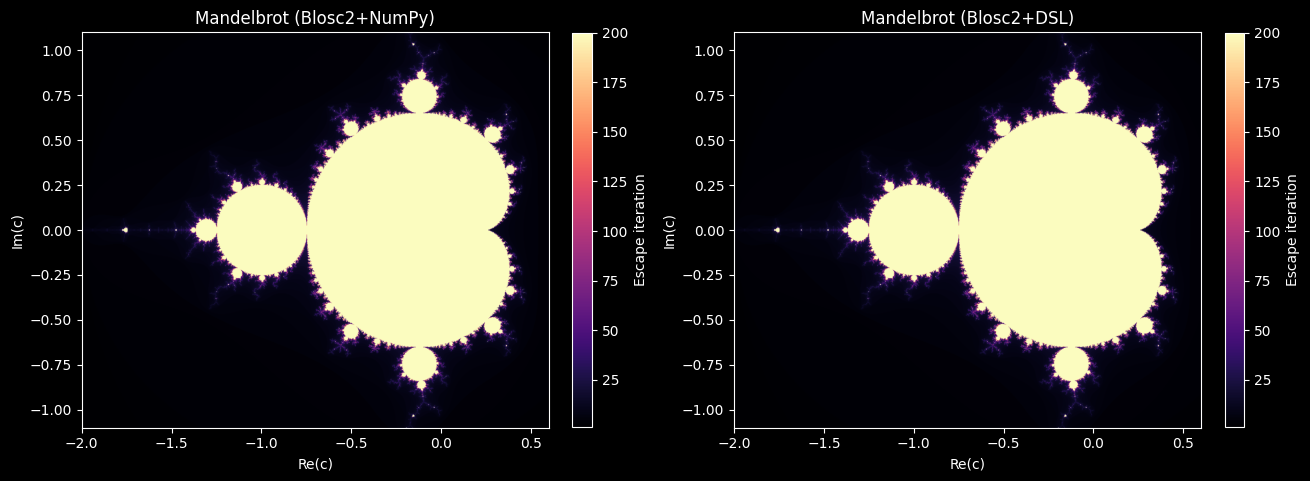

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

im0 = ax[0].imshow(
    img_numpy,
    cmap="magma",
    extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
    origin="lower",
)
ax[0].set_title("Mandelbrot (Blosc2+NumPy)")
ax[0].set_xlabel("Re(c)")
ax[0].set_ylabel("Im(c)")
fig.colorbar(im0, ax=ax[0], shrink=0.82, label="Escape iteration")

im1 = ax[1].imshow(
    img_dsl,
    cmap="magma",
    extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
    origin="lower",
)
ax[1].set_title("Mandelbrot (Blosc2+DSL)")
ax[1].set_xlabel("Re(c)")
ax[1].set_ylabel("Im(c)")
fig.colorbar(im1, ax=ax[1], shrink=0.82, label="Escape iteration")

plt.show()

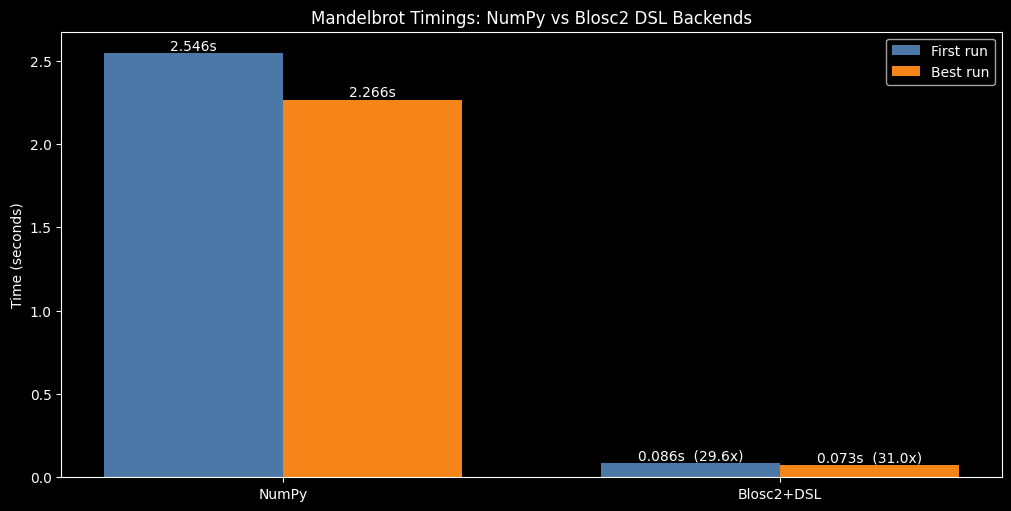

In [7]:
labels = ["NumPy", "Blosc2+DSL"]
first_times = [t_numpy_first, t_dsl_first]
best_times = [t_numpy, t_dsl]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.bar(x - width / 2, first_times, width, label="First run", color="#4C78A8")
ax.bar(x + width / 2, best_times, width, label="Best run", color="#F58518")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Time (seconds)")
ax.set_title("Mandelbrot Timings: NumPy vs Blosc2 DSL Backends")
ax.legend()

speedup_first = first_times[0] / first_times[1]
speedup_best = best_times[0] / best_times[1]
for i, t in enumerate(first_times):
    label = f"{t:.3f}s"
    if i == 1:
        label += f"  ({speedup_first:.1f}x)"
    ax.text(i - width / 2, t, label, ha="center", va="bottom")
for i, t in enumerate(best_times):
    label = f"{t:.3f}s"
    if i == 1:
        label += f"  ({speedup_best:.1f}x)"
    ax.text(i + width / 2, t, label, ha="center", va="bottom")

plt.show()